# Анализ алгоритмического выделения областей интереса на SAR-изображениях

Этот ноутбук подготавливает вспомогательную доказательную базу для главы ВКР: он анализирует не полноценную сегментацию с ручными масками, а **алгоритмическое выделение областей интереса** (`area selection`, `ROI extraction`) на SAR-изображениях.

Главный фокус: показать, как характеристики качества входных снимков связаны со стабильностью выделения областей, и почему предварительное улучшение качества может быть полезным этапом перед downstream-алгоритмами.

Важно для текста диплома: результаты этого notebook следует использовать **частично и осторожно**. Модуль выделения областей не является основным вкладом работы; он нужен как контекст для утверждения, что улучшение качества снимков может снижать шумовую фрагментацию и стабилизировать поиск областей.

## План эксперимента

В репозитории нет набора ground truth-масок для пиксельной сегментации, поэтому здесь не считаются Dice, mIoU и pixel accuracy как итоговые метрики. Вместо этого используются метрики алгоритмического выделения областей:

- число найденных областей интереса на изображение;
- суммарное покрытие кадра ROI;
- средняя и медианная площадь ROI;
- доля очень маленьких областей как признак шумовой фрагментации;
- распределение размеров bounding box;
- overlap/IoU между областями на исходном и мягко улучшенном изображении;
- связь ROI-метрик с яркостью, контрастом, шумностью и резкостью из предыдущего EDA.

Такой протокол не доказывает качество сегментации в строгом смысле, но показывает инженерно важную устойчивость этапа выделения областей.

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, ImageOps
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "sources" / "work-materials" / "images 2").exists():
            return candidate
    raise FileNotFoundError("Cannot find sources/work-materials/images 2")


PROJECT_ROOT = find_project_root()
INPUT_DIR = PROJECT_ROOT / "sources" / "work-materials" / "images 2"
QUALITY_EDA_DIR = PROJECT_ROOT / "evidence" / "experiments" / "2026-05-14-sar-image-quality-eda-assets"
QUALITY_TABLE_PATH = QUALITY_EDA_DIR / "sar_image_quality_scored.csv"
OUTPUT_DIR = PROJECT_ROOT / "evidence" / "experiments" / "2026-05-14-sar-area-selection-quality-analysis-assets"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}

print(f"Project root: {PROJECT_ROOT}")
print(f"Input dir:    {INPUT_DIR}")
print(f"Quality EDA:  {QUALITY_TABLE_PATH}")
print(f"Output dir:   {OUTPUT_DIR}")

Project root: /Users/bykovskiy.mihail/Documents/diploma_agent
Input dir:    /Users/bykovskiy.mihail/Documents/diploma_agent/sources/work-materials/images 2
Quality EDA:  /Users/bykovskiy.mihail/Documents/diploma_agent/evidence/experiments/2026-05-14-sar-image-quality-eda-assets/sar_image_quality_scored.csv
Output dir:   /Users/bykovskiy.mihail/Documents/diploma_agent/evidence/experiments/2026-05-14-sar-area-selection-quality-analysis-assets


## 1. Данные и связь с предыдущим EDA

Входными изображениями являются те же SAR-файлы, что и в анализе качества. Это позволяет связать поведение алгоритма выделения областей с уже рассчитанными характеристиками: яркостью, контрастом, шумностью, резкостью и интегральным индексом сложности изображения.

In [2]:
image_paths = sorted(
    p for p in INPUT_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
)

quality_df = pd.read_csv(QUALITY_TABLE_PATH)
quality_df["path"] = quality_df["path"].astype(str)

print(f"Images found: {len(image_paths)}")
print(f"Quality rows: {len(quality_df)}")
display(quality_df[["filename", "mean_luma", "std_luma", "speckle_noise_score", "detail_score", "quality_challenge_score"]].head())

Images found: 92
Quality rows: 92


,filename,mean_luma,std_luma,speckle_noise_score,detail_score,quality_challenge_score
0,1.jpg,42.886925,50.905350,0.712578,0.797103,0.399555
1,2.jpg,49.324474,51.427742,0.722034,0.892731,0.343222
2,2333.jpg,19.400669,16.479340,0.228379,0.053468,0.745773
3,3.jpg,66.976463,44.447018,0.615695,0.916089,0.256031
4,4.jpg,74.812263,58.202396,0.744773,0.972597,0.213668


## 2. Алгоритм выделения областей

Для воспроизводимости в notebook реализована легкая версия area-selection пайплайна:

1. изображение переводится в яркостное представление и нормализуется;
2. выполняется мягкая предварительная обработка для варианта `enhanced`: подавление спекл-подобной зернистости и локальное усиление контраста;
3. строятся две карты кандидатов: локальная энергия/вариативность и CFAR-подобный порог по фону;
4. карты объединяются, очищаются морфологическими операциями;
5. по connected components извлекаются bounding boxes;
6. применяются фильтры площади и NMS по IoU.

Это не ручная сегментация и не обучение модели. Это инженерный анализ устойчивости выделения областей интереса.

In [3]:
def load_gray_uint8(path: Path) -> np.ndarray:
    with Image.open(path) as img:
        img = ImageOps.exif_transpose(img)
        return np.asarray(img.convert("L"), dtype=np.uint8)


def resize_for_roi(gray: np.ndarray, max_side: int = 768) -> tuple[np.ndarray, float]:
    """Downsample image for stable and fast ROI analysis; return image and scale to original."""
    h, w = gray.shape
    scale = min(1.0, max_side / max(h, w))
    if scale == 1.0:
        return gray, 1.0
    resized = cv2.resize(gray, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    return resized, scale


def mild_quality_enhancement(gray: np.ndarray) -> np.ndarray:
    """Mild preprocessing: denoise speckle-like grain and improve local contrast."""
    denoised = cv2.fastNlMeansDenoising(gray, None, h=8, templateWindowSize=7, searchWindowSize=21)
    clahe = cv2.createCLAHE(clipLimit=1.6, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)
    # Conservative blend reduces the risk of over-amplifying noise.
    return cv2.addWeighted(gray, 0.35, enhanced, 0.65, 0)


def compute_tile_mask(img_float: np.ndarray, tile: int = 96) -> np.ndarray:
    mean = cv2.boxFilter(img_float, ddepth=-1, ksize=(tile, tile), normalize=True, borderType=cv2.BORDER_REFLECT)
    mean_sq = cv2.boxFilter(img_float * img_float, ddepth=-1, ksize=(tile, tile), normalize=True, borderType=cv2.BORDER_REFLECT)
    var = np.maximum(mean_sq - mean * mean, 0)
    energy = cv2.normalize(mean_sq, None, 0, 1, cv2.NORM_MINMAX)
    entropy_proxy = cv2.normalize(var, None, 0, 1, cv2.NORM_MINMAX)
    return ((energy > 0.55) | (entropy_proxy > 0.55)).astype(np.uint8) * 255


def cfar_like_mask(gray: np.ndarray, guard: int = 2, train: int = 12, k: float = 2.3) -> np.ndarray:
    img = np.log1p(gray.astype(np.float32))
    img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    win = 2 * (guard + train) + 1
    if win % 2 == 0:
        win += 1
    background = cv2.medianBlur(img_norm, win)
    threshold = background.astype(np.float32) * float(k)
    return (img_norm.astype(np.float32) > threshold).astype(np.uint8) * 255


def box_iou(a: tuple[int, int, int, int], b: tuple[int, int, int, int]) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter
    return float(inter / union) if union > 0 else 0.0


def nms_boxes(boxes: list[dict], iou_threshold: float = 0.55) -> list[dict]:
    kept: list[dict] = []
    for cand in sorted(boxes, key=lambda x: x["score"], reverse=True):
        cand_box = (cand["x1"], cand["y1"], cand["x2"], cand["y2"])
        if all(box_iou(cand_box, (k["x1"], k["y1"], k["x2"], k["y2"])) < iou_threshold for k in kept):
            kept.append(cand)
    return kept


def extract_rois(gray_original: np.ndarray, variant: str, max_side: int = 768) -> tuple[list[dict], np.ndarray, np.ndarray]:
    # Resize first: NLM denoising on full 1536x1536 frames makes notebook execution unnecessarily slow.
    gray_resized, scale = resize_for_roi(gray_original, max_side=max_side)
    if variant == "enhanced":
        gray = mild_quality_enhancement(gray_resized)
    elif variant == "original":
        gray = gray_resized.copy()
    else:
        raise ValueError(f"Unknown variant: {variant}")

    img_float = gray.astype(np.float32)
    img_float = cv2.GaussianBlur(img_float, (3, 3), 0)

    tile_mask = compute_tile_mask(img_float)
    cfar_mask = cfar_like_mask(gray)
    mask = cv2.bitwise_or(tile_mask, cfar_mask)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=1)
    mask = cv2.dilate(mask, np.ones((3, 3), np.uint8), iterations=1)

    num, labels, stats, _ = cv2.connectedComponentsWithStats((mask > 0).astype(np.uint8), connectivity=8)
    h, w = gray.shape
    img_area = h * w
    boxes: list[dict] = []
    for idx in range(1, num):
        x, y, bw, bh, area = stats[idx]
        if area < max(12, 0.000015 * img_area):
            continue
        if area > 0.35 * img_area:
            continue
        aspect = bw / max(bh, 1)
        if aspect < 0.08 or aspect > 12:
            continue
        component_mask = labels[y:y + bh, x:x + bw] == idx
        local_values = gray[y:y + bh, x:x + bw][component_mask]
        score = float(local_values.mean() + 0.5 * local_values.std()) if local_values.size else 0.0
        boxes.append({
            "x1": int(x), "y1": int(y), "x2": int(x + bw), "y2": int(y + bh),
            "area_px": int(area), "bbox_area_px": int(bw * bh), "width": int(bw), "height": int(bh),
            "aspect_ratio": float(aspect), "score": score,
        })

    boxes = nms_boxes(boxes, iou_threshold=0.55)[:200]
    return boxes, mask, gray

In [4]:
def summarize_rois(filename: str, variant: str, gray_shape: tuple[int, int], boxes: list[dict], mask: np.ndarray) -> dict:
    h, w = gray_shape
    image_area = h * w
    roi_count = len(boxes)
    component_areas = np.array([b["area_px"] for b in boxes], dtype=float) if boxes else np.array([], dtype=float)
    bbox_areas = np.array([b["bbox_area_px"] for b in boxes], dtype=float) if boxes else np.array([], dtype=float)
    widths = np.array([b["width"] for b in boxes], dtype=float) if boxes else np.array([], dtype=float)
    heights = np.array([b["height"] for b in boxes], dtype=float) if boxes else np.array([], dtype=float)

    tiny_area_threshold = 0.0001 * image_area
    small_area_threshold = 0.001 * image_area

    return {
        "filename": filename,
        "variant": variant,
        "roi_count": roi_count,
        "mask_coverage_ratio": float((mask > 0).mean()),
        "roi_component_area_sum_ratio": float(component_areas.sum() / image_area) if roi_count else 0.0,
        "roi_bbox_area_sum_ratio": float(bbox_areas.sum() / image_area) if roi_count else 0.0,
        "roi_area_mean": float(component_areas.mean()) if roi_count else 0.0,
        "roi_area_median": float(np.median(component_areas)) if roi_count else 0.0,
        "roi_area_p95": float(np.percentile(component_areas, 95)) if roi_count else 0.0,
        "bbox_width_median": float(np.median(widths)) if roi_count else 0.0,
        "bbox_height_median": float(np.median(heights)) if roi_count else 0.0,
        "tiny_roi_ratio": float((component_areas < tiny_area_threshold).mean()) if roi_count else 0.0,
        "small_roi_ratio": float((component_areas < small_area_threshold).mean()) if roi_count else 0.0,
    }


def roi_overlap_metrics(original_boxes: list[dict], enhanced_boxes: list[dict]) -> dict:
    if not original_boxes and not enhanced_boxes:
        return {
            "matched_original_ratio": 1.0,
            "matched_enhanced_ratio": 1.0,
            "mean_best_iou_original_to_enhanced": 1.0,
            "mean_best_iou_enhanced_to_original": 1.0,
            "overlap_roi_count_delta": 0,
            "overlap_roi_count_delta_ratio": 0.0,
        }
    if not original_boxes or not enhanced_boxes:
        return {
            "matched_original_ratio": 0.0,
            "matched_enhanced_ratio": 0.0,
            "mean_best_iou_original_to_enhanced": 0.0,
            "mean_best_iou_enhanced_to_original": 0.0,
            "overlap_roi_count_delta": len(enhanced_boxes) - len(original_boxes),
            "overlap_roi_count_delta_ratio": (len(enhanced_boxes) - len(original_boxes)) / max(len(original_boxes), 1),
        }

    orig = [(b["x1"], b["y1"], b["x2"], b["y2"]) for b in original_boxes]
    enh = [(b["x1"], b["y1"], b["x2"], b["y2"]) for b in enhanced_boxes]
    best_o2e = np.array([max(box_iou(a, b) for b in enh) for a in orig])
    best_e2o = np.array([max(box_iou(a, b) for a in orig) for b in enh])
    return {
        "matched_original_ratio": float((best_o2e >= 0.3).mean()),
        "matched_enhanced_ratio": float((best_e2o >= 0.3).mean()),
        "mean_best_iou_original_to_enhanced": float(best_o2e.mean()),
        "mean_best_iou_enhanced_to_original": float(best_e2o.mean()),
        "overlap_roi_count_delta": len(enhanced_boxes) - len(original_boxes),
        "overlap_roi_count_delta_ratio": (len(enhanced_boxes) - len(original_boxes)) / max(len(original_boxes), 1),
    }

## 3. Запуск выделения областей на исходных и мягко улучшенных изображениях

Для каждого изображения строятся две версии ROI:

- `original` — выделение областей на исходном снимке;
- `enhanced` — выделение областей после мягкого улучшения: подавления зернистости и локального контрастирования.

Сравнение этих двух вариантов не является сравнением «правильно/неправильно» без ground truth, но позволяет оценить стабильность алгоритма и изменение шумовой фрагментации.

In [5]:
summary_rows = []
overlap_rows = []
box_rows = []
preview_cache = {}
errors = []

for path in tqdm(image_paths, desc="Running ROI extraction"):
    try:
        gray_original = load_gray_uint8(path)
        original_boxes, original_mask, original_work = extract_rois(gray_original, variant="original")
        enhanced_boxes, enhanced_mask, enhanced_work = extract_rois(gray_original, variant="enhanced")

        summary_rows.append(summarize_rois(path.name, "original", original_work.shape, original_boxes, original_mask))
        summary_rows.append(summarize_rois(path.name, "enhanced", enhanced_work.shape, enhanced_boxes, enhanced_mask))

        overlap = roi_overlap_metrics(original_boxes, enhanced_boxes)
        overlap_rows.append({"filename": path.name, **overlap})

        for variant, boxes in [("original", original_boxes), ("enhanced", enhanced_boxes)]:
            for idx, box in enumerate(boxes):
                box_rows.append({"filename": path.name, "variant": variant, "roi_idx": idx, **box})

        # Keep small cache only for later visual examples.
        preview_cache[path.name] = {
            "original_image": original_work,
            "enhanced_image": enhanced_work,
            "original_mask": original_mask,
            "enhanced_mask": enhanced_mask,
            "original_boxes": original_boxes,
            "enhanced_boxes": enhanced_boxes,
        }
    except Exception as exc:
        errors.append({"filename": path.name, "error": repr(exc)})

roi_summary_df = pd.DataFrame(summary_rows)
roi_overlap_df = pd.DataFrame(overlap_rows)
roi_boxes_df = pd.DataFrame(box_rows)
roi_errors_df = pd.DataFrame(errors)

roi_summary_path = OUTPUT_DIR / "sar_area_selection_roi_summary.csv"
roi_overlap_path = OUTPUT_DIR / "sar_area_selection_roi_overlap.csv"
roi_boxes_path = OUTPUT_DIR / "sar_area_selection_roi_boxes.csv"
roi_errors_path = OUTPUT_DIR / "sar_area_selection_errors.csv"

roi_summary_df.to_csv(roi_summary_path, index=False)
roi_overlap_df.to_csv(roi_overlap_path, index=False)
roi_boxes_df.to_csv(roi_boxes_path, index=False)
if len(roi_errors_df):
    roi_errors_df.to_csv(roi_errors_path, index=False)

print(f"Summary rows: {len(roi_summary_df)}")
print(f"Overlap rows: {len(roi_overlap_df)}")
print(f"Box rows: {len(roi_boxes_df)}")
print(f"Errors: {len(roi_errors_df)}")
display(roi_summary_df.head())

Running ROI extraction:   0%|          | 0/92 [00:00<?, ?it/s]

Summary rows: 184
Overlap rows: 92
Box rows: 957
Errors: 0


,filename,variant,roi_count,mask_coverage_ratio,roi_component_area_sum_ratio,roi_bbox_area_sum_ratio,roi_area_mean,roi_area_median,roi_area_p95,bbox_width_median,bbox_height_median,tiny_roi_ratio,small_roi_ratio
0,1.jpg,original,6,0.112412,0.112412,0.168682,7674.000000,5033.0,18963.75,79.5,97.5,0.000000,0.000000
1,1.jpg,enhanced,13,0.228943,0.228943,0.424858,7213.461538,4660.0,25187.60,99.0,85.0,0.076923,0.384615
2,2.jpg,original,2,0.046301,0.046301,0.072012,9482.500000,9482.5,10918.45,128.5,113.0,0.000000,0.000000
3,2.jpg,enhanced,4,0.079431,0.079431,0.125059,8133.750000,4894.0,20486.30,72.5,77.0,0.000000,0.250000
4,2333.jpg,original,4,0.053267,0.053267,0.055662,7854.500000,8926.5,9175.35,96.5,95.5,0.000000,0.000000


## 4. Сводная статистика ROI

Эта часть показывает, насколько сильно меняются характеристики выделенных областей при мягком улучшении качества. Наиболее полезные признаки для дипломного текста: изменение количества ROI, снижение доли мелких областей и изменение покрытия кадра.

In [6]:
roi_metric_cols = [
    "roi_count", "mask_coverage_ratio", "roi_component_area_sum_ratio",
    "roi_bbox_area_sum_ratio", "roi_area_mean", "roi_area_median",
    "bbox_width_median", "bbox_height_median", "tiny_roi_ratio", "small_roi_ratio",
]

roi_stats = roi_summary_df.groupby("variant")[roi_metric_cols].agg(["mean", "median", "std", "min", "max"])
roi_stats.to_csv(OUTPUT_DIR / "sar_area_selection_roi_stats_by_variant.csv")
display(roi_stats.round(4))

pivot = roi_summary_df.pivot(index="filename", columns="variant", values=roi_metric_cols)
comparison_df = pd.DataFrame({"filename": pivot.index})
for col in roi_metric_cols:
    comparison_df[f"{col}_original"] = pivot[(col, "original")].values
    comparison_df[f"{col}_enhanced"] = pivot[(col, "enhanced")].values
    comparison_df[f"{col}_delta"] = comparison_df[f"{col}_enhanced"] - comparison_df[f"{col}_original"]
    comparison_df[f"{col}_delta_ratio"] = comparison_df[f"{col}_delta"] / comparison_df[f"{col}_original"].replace(0, np.nan)

comparison_df = comparison_df.merge(roi_overlap_df, on="filename", how="left")
comparison_df.to_csv(OUTPUT_DIR / "sar_area_selection_original_vs_enhanced.csv", index=False)
display(comparison_df.head())

roi_count                        mask_coverage_ratio                  \
              mean median     std min max                mean  median     std   
variant                                                                         
enhanced    5.8261    5.5  3.2161   1  14              0.0980  0.0820  0.0882   
original    4.5761    4.0  2.8293   1  14              0.0718  0.0548  0.0535   

                          ... tiny_roi_ratio                            \
             min     max  ...           mean median     std  min   max   
variant                   ...                                            
enhanced  0.0163  0.5344  ...         0.1214    0.0  0.1888  0.0  0.75   
original  0.0061  0.2558  ...         0.0506    0.0  0.1227  0.0  0.60   

         small_roi_ratio                               
                    mean  median     std  min     max  
variant                                                
enhanced          0.2482  0.2222  0.2468  0.0  0.7857  
original          0.1570  0.0000  0.2034  0.0  0.7500  

[2 rows x 50 columns]

,filename,roi_count_original,roi_count_enhanced,roi_count_delta,roi_count_delta_ratio,mask_coverage_ratio_original,mask_coverage_ratio_enhanced,mask_coverage_ratio_delta,mask_coverage_ratio_delta_ratio,roi_component_area_sum_ratio_original,...,small_roi_ratio_original,small_roi_ratio_enhanced,small_roi_ratio_delta,small_roi_ratio_delta_ratio,matched_original_ratio,matched_enhanced_ratio,mean_best_iou_original_to_enhanced,mean_best_iou_enhanced_to_original,overlap_roi_count_delta,overlap_roi_count_delta_ratio
0,1.jpg,6.0,13.0,7.0,1.166667,0.112412,0.228943,0.116531,1.036639,0.112412,...,0.000000,0.384615,0.384615,NaN,0.500000,0.230769,0.401321,0.178226,7,1.166667
1,2.jpg,2.0,4.0,2.0,1.000000,0.046301,0.079431,0.033130,0.715529,0.046301,...,0.000000,0.250000,0.250000,NaN,1.000000,0.500000,0.728728,0.364364,2,1.000000
2,2333.jpg,4.0,4.0,0.0,0.000000,0.053267,0.054621,0.001355,0.025431,0.053267,...,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,0.937068,0.937068,0,0.000000
3,3.jpg,8.0,5.0,-3.0,-0.375000,0.166375,0.422839,0.256465,1.541491,0.166375,...,0.125000,0.200000,0.075000,0.600000,0.000000,0.000000,0.000000,0.000000,-3,-0.375000
4,4.jpg,13.0,6.0,-7.0,-0.538462,0.227856,0.534407,0.306550,1.345366,0.227856,...,0.692308,0.666667,-0.025641,-0.037037,0.076923,0.166667,0.066903,0.138624,-7,-0.538462


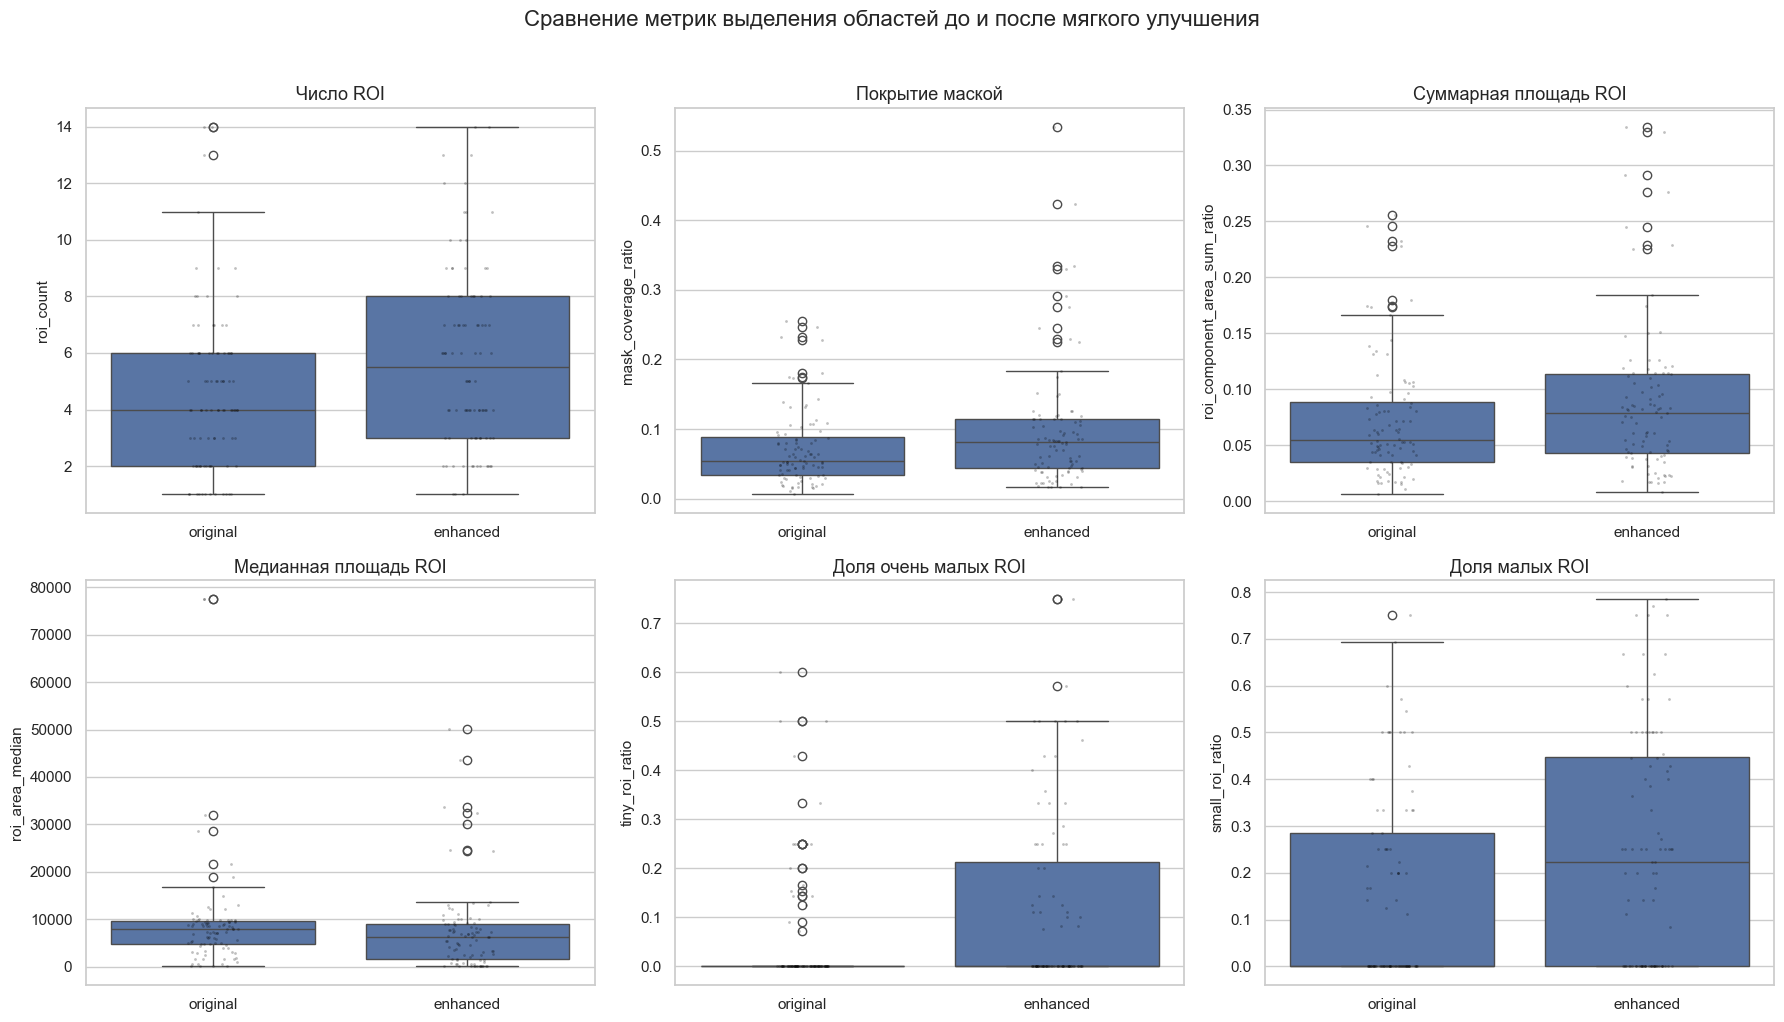

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_cols = [
    ("roi_count", "Число ROI"),
    ("mask_coverage_ratio", "Покрытие маской"),
    ("roi_component_area_sum_ratio", "Суммарная площадь ROI"),
    ("roi_area_median", "Медианная площадь ROI"),
    ("tiny_roi_ratio", "Доля очень малых ROI"),
    ("small_roi_ratio", "Доля малых ROI"),
]

for ax, (col, title) in zip(axes.ravel(), plot_cols):
    sns.boxplot(data=roi_summary_df, x="variant", y=col, ax=ax)
    sns.stripplot(data=roi_summary_df, x="variant", y=col, ax=ax, color="black", alpha=0.25, size=2)
    ax.set_title(title)
    ax.set_xlabel("")

fig.suptitle("Сравнение метрик выделения областей до и после мягкого улучшения", y=1.02, fontsize=16)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "area_selection_metrics_by_variant.png", dpi=220, bbox_inches="tight")
plt.show()

## 5. Связь качества изображения и выделения областей

Теперь объединим ROI-метрики с предыдущим EDA качества изображений. Нас интересует не абсолютная точность без разметки, а зависимость поведения алгоритма от входных свойств снимка: темноты, контраста, шумности и детализации.

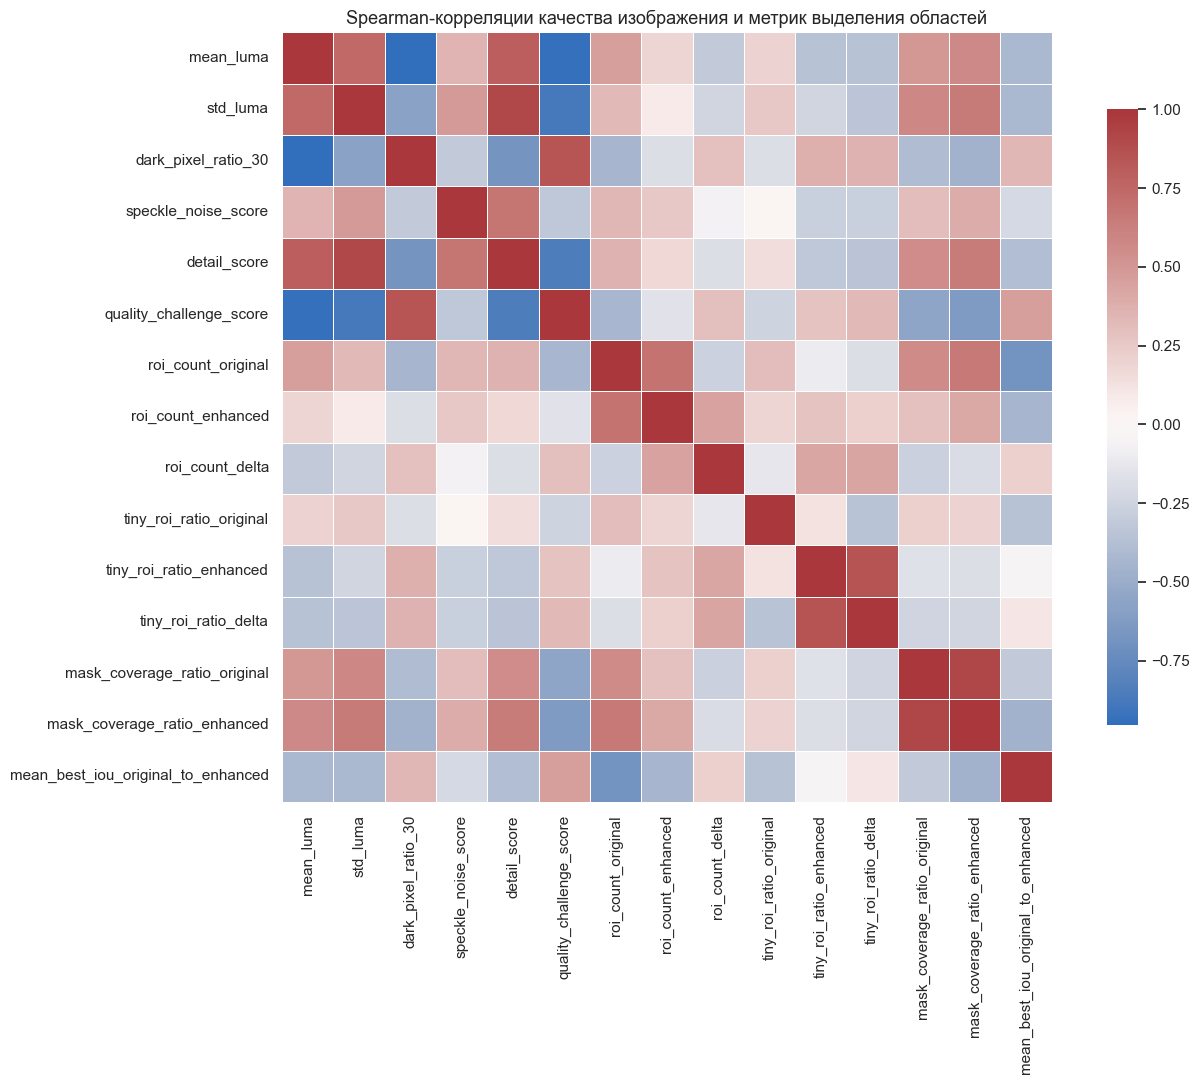

,filename,mean_luma,std_luma,speckle_noise_score,roi_count_original,roi_count_enhanced,roi_count_delta,mean_best_iou_original_to_enhanced
0,1.jpg,42.886925,50.905350,0.712578,6.0,13.0,7.0,0.401321
1,2.jpg,49.324474,51.427742,0.722034,2.0,4.0,2.0,0.728728
2,2333.jpg,19.400669,16.479340,0.228379,4.0,4.0,0.0,0.937068
3,3.jpg,66.976463,44.447018,0.615695,8.0,5.0,-3.0,0.000000
4,4.jpg,74.812263,58.202396,0.744773,13.0,6.0,-7.0,0.066903


In [8]:
quality_cols = [
    "filename", "mean_luma", "std_luma", "robust_dynamic_range", "entropy_bits",
    "dark_pixel_ratio_30", "speckle_noise_score", "detail_score", "quality_challenge_score",
    "high_freq_residual_std", "local_cv_mean", "laplacian_var", "edge_density",
]

analysis_df = comparison_df.merge(quality_df[quality_cols], on="filename", how="left")
analysis_path = OUTPUT_DIR / "sar_area_selection_quality_joined.csv"
analysis_df.to_csv(analysis_path, index=False)

corr_cols = [
    "mean_luma", "std_luma", "dark_pixel_ratio_30", "speckle_noise_score", "detail_score", "quality_challenge_score",
    "roi_count_original", "roi_count_enhanced", "roi_count_delta",
    "tiny_roi_ratio_original", "tiny_roi_ratio_enhanced", "tiny_roi_ratio_delta",
    "mask_coverage_ratio_original", "mask_coverage_ratio_enhanced", "mean_best_iou_original_to_enhanced",
]

corr = analysis_df[corr_cols].corr(method="spearman")
plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Spearman-корреляции качества изображения и метрик выделения областей")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "area_selection_quality_correlations.png", dpi=220, bbox_inches="tight")
plt.show()

display(analysis_df[["filename", "mean_luma", "std_luma", "speckle_noise_score", "roi_count_original", "roi_count_enhanced", "roi_count_delta", "mean_best_iou_original_to_enhanced"]].head())

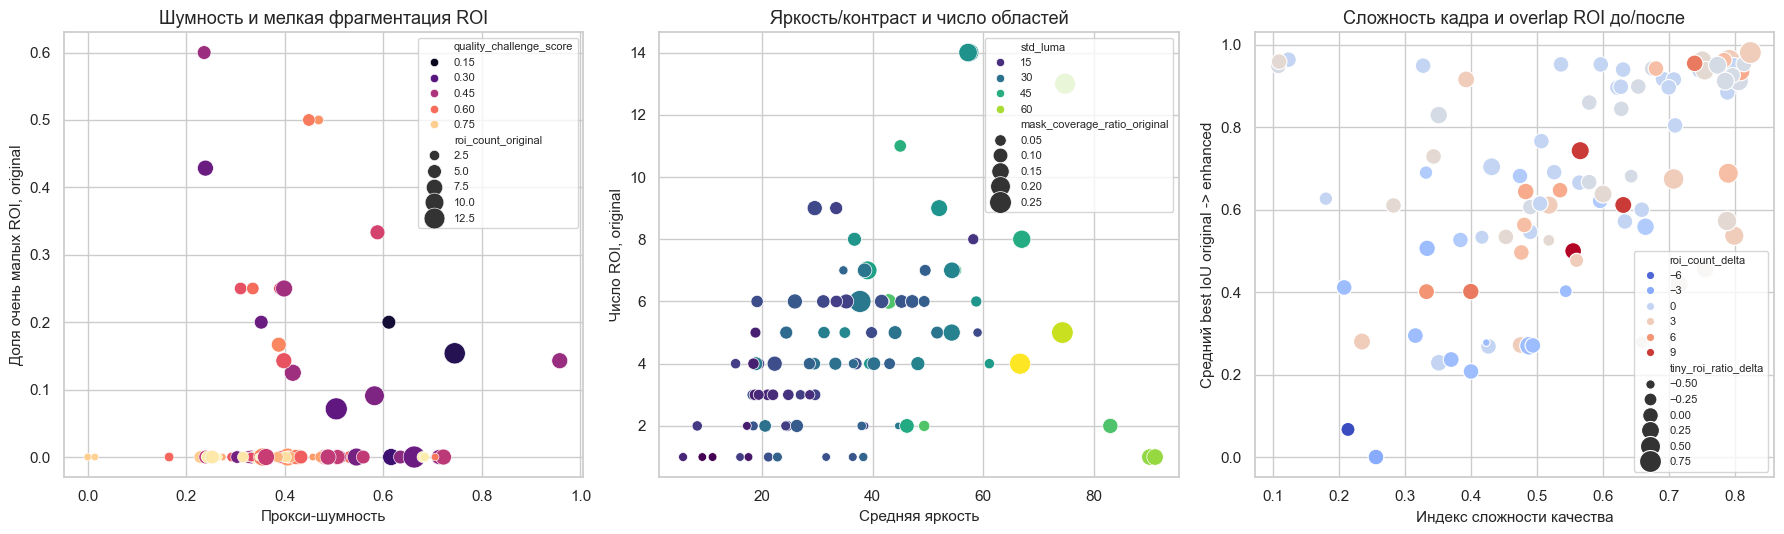

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

sns.scatterplot(
    data=analysis_df,
    x="speckle_noise_score",
    y="tiny_roi_ratio_original",
    hue="quality_challenge_score",
    size="roi_count_original",
    palette="magma",
    sizes=(30, 250),
    ax=axes[0],
)
axes[0].set_title("Шумность и мелкая фрагментация ROI")
axes[0].set_xlabel("Прокси-шумность")
axes[0].set_ylabel("Доля очень малых ROI, original")

sns.scatterplot(
    data=analysis_df,
    x="mean_luma",
    y="roi_count_original",
    hue="std_luma",
    size="mask_coverage_ratio_original",
    palette="viridis",
    sizes=(30, 250),
    ax=axes[1],
)
axes[1].set_title("Яркость/контраст и число областей")
axes[1].set_xlabel("Средняя яркость")
axes[1].set_ylabel("Число ROI, original")

sns.scatterplot(
    data=analysis_df,
    x="quality_challenge_score",
    y="mean_best_iou_original_to_enhanced",
    hue="roi_count_delta",
    size="tiny_roi_ratio_delta" if analysis_df["tiny_roi_ratio_delta"].notna().any() else None,
    palette="coolwarm",
    sizes=(30, 250),
    ax=axes[2],
)
axes[2].set_title("Сложность кадра и overlap ROI до/после")
axes[2].set_xlabel("Индекс сложности качества")
axes[2].set_ylabel("Средний best IoU original -> enhanced")

for ax in axes:
    ax.legend(loc="best", fontsize=8)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "area_selection_quality_scatterplots.png", dpi=220, bbox_inches="tight")
plt.show()

## 6. Визуальные примеры выделения областей

Для отчета полезны не только агрегированные метрики, но и несколько диагностических изображений. Ниже выбираются кадры с наибольшим изменением числа областей и с наиболее сложным качеством по предыдущему EDA. На них показаны ROI до и после мягкого улучшения качества.

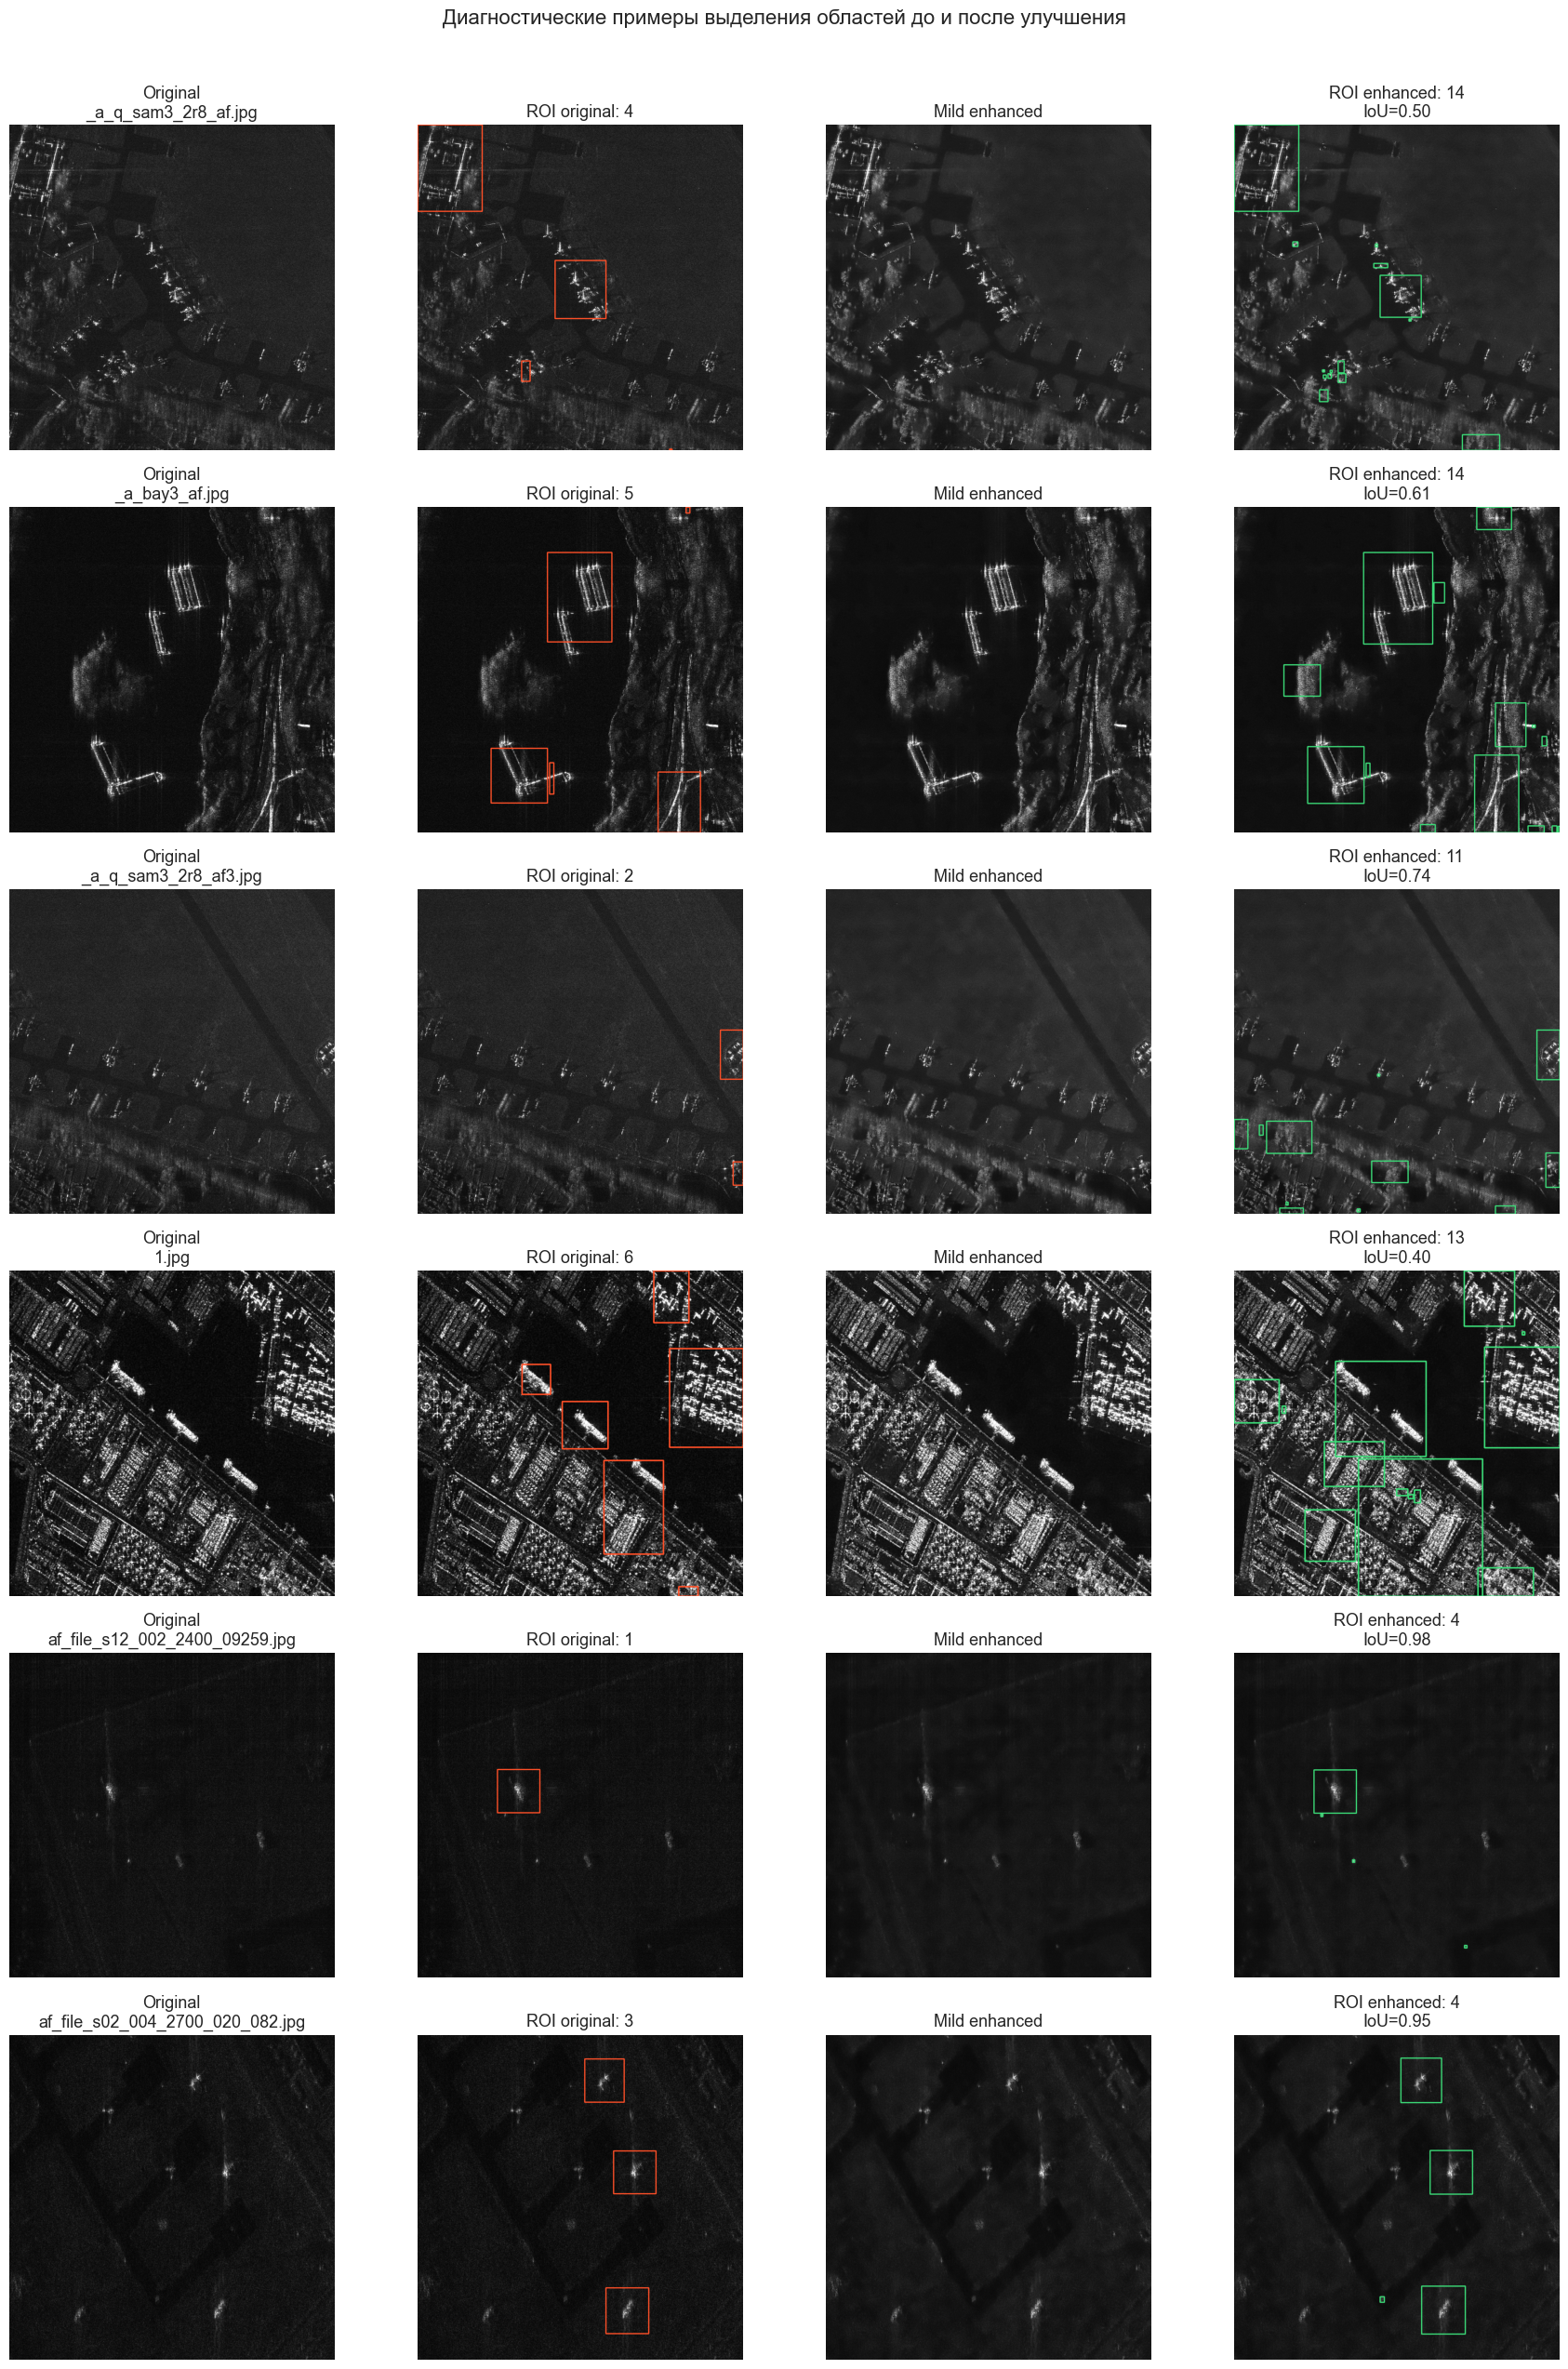

,filename,quality_challenge_score,roi_count_original,roi_count_enhanced,roi_count_delta,tiny_roi_ratio_original,tiny_roi_ratio_enhanced,mean_best_iou_original_to_enhanced
0,1.jpg,0.399555,6.0,13.0,7.0,0.00,0.076923,0.401321
22,_a_bay3_af.jpg,0.630375,5.0,14.0,9.0,0.00,0.142857,0.611065
25,_a_q_sam3_2r8_af.jpg,0.554444,4.0,14.0,10.0,0.25,0.357143,0.499496
26,_a_q_sam3_2r8_af3.jpg,0.565166,2.0,11.0,9.0,0.00,0.272727,0.742640
79,af_file_s02_004_2700_020_082.jpg,0.812886,3.0,4.0,1.0,0.00,0.000000,0.952949
82,af_file_s12_002_2400_09259.jpg,0.822747,1.0,4.0,3.0,0.00,0.750000,0.980583


In [10]:
def draw_boxes(gray: np.ndarray, boxes: list[dict], color=(255, 80, 40)) -> np.ndarray:
    rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    for box in boxes:
        cv2.rectangle(rgb, (box["x1"], box["y1"]), (box["x2"], box["y2"]), color, 2)
    return rgb


def show_roi_comparison(filenames: list[str], title: str) -> None:
    n = len(filenames)
    fig, axes = plt.subplots(n, 4, figsize=(18, 4.2 * n))
    axes = np.atleast_2d(axes)
    for row_idx, filename in enumerate(filenames):
        cache = preview_cache[filename]
        original_overlay = draw_boxes(cache["original_image"], cache["original_boxes"], color=(255, 80, 40))
        enhanced_overlay = draw_boxes(cache["enhanced_image"], cache["enhanced_boxes"], color=(60, 220, 120))
        row = analysis_df.loc[analysis_df["filename"] == filename].iloc[0]

        axes[row_idx, 0].imshow(cache["original_image"], cmap="gray", vmin=0, vmax=255)
        axes[row_idx, 0].set_title(f"Original\n{filename}")
        axes[row_idx, 1].imshow(original_overlay)
        axes[row_idx, 1].set_title(f"ROI original: {int(row['roi_count_original'])}")
        axes[row_idx, 2].imshow(cache["enhanced_image"], cmap="gray", vmin=0, vmax=255)
        axes[row_idx, 2].set_title("Mild enhanced")
        axes[row_idx, 3].imshow(enhanced_overlay)
        axes[row_idx, 3].set_title(f"ROI enhanced: {int(row['roi_count_enhanced'])}\nIoU={row['mean_best_iou_original_to_enhanced']:.2f}")

        for ax in axes[row_idx]:
            ax.axis("off")
    fig.suptitle(title, fontsize=16, y=1.01)
    fig.tight_layout()
    safe_name = "".join(ch if ch.isalnum() else "_" for ch in title.lower())[:80]
    fig.savefig(OUTPUT_DIR / f"{safe_name}.png", dpi=180, bbox_inches="tight")
    plt.show()

selected_change = analysis_df.assign(abs_roi_count_delta=analysis_df["roi_count_delta"].abs()).nlargest(4, "abs_roi_count_delta")["filename"].tolist()
selected_hard = analysis_df.nlargest(4, "quality_challenge_score")["filename"].tolist()
selected_examples = list(dict.fromkeys(selected_change + selected_hard))[:6]

show_roi_comparison(selected_examples, "Диагностические примеры выделения областей до и после улучшения")

analysis_df.loc[analysis_df["filename"].isin(selected_examples), [
    "filename", "quality_challenge_score", "roi_count_original", "roi_count_enhanced", "roi_count_delta",
    "tiny_roi_ratio_original", "tiny_roi_ratio_enhanced", "mean_best_iou_original_to_enhanced",
]].to_csv(OUTPUT_DIR / "selected_area_selection_examples.csv", index=False)

display(analysis_df.loc[analysis_df["filename"].isin(selected_examples), [
    "filename", "quality_challenge_score", "roi_count_original", "roi_count_enhanced", "roi_count_delta",
    "tiny_roi_ratio_original", "tiny_roi_ratio_enhanced", "mean_best_iou_original_to_enhanced",
]])

## 7. Формализация метрик для главы

Пусть алгоритм выделения областей получает изображение

\[
I \in \{0, \ldots, 255\}^{H \times W}
\]

и возвращает множество областей

\[
R(I) = \{r_1, r_2, \ldots, r_n\}, \quad r_i = (x_1, y_1, x_2, y_2, s_i),
\]

где `r_i` — bounding box области интереса, а `s_i` — эвристическая оценка выраженности области.

Так как ручных масок в данном протоколе нет, итоговая оценка задается не через pixel-level Dice/mIoU, а через вспомогательные показатели:

\[
N(I) = |R(I)|,
\]

\[
C(I) = \frac{1}{HW}\sum_{r_i \in R(I)} area(r_i),
\]

\[
S_{small}(I) = \frac{|\{r_i: area(r_i) < \tau\}|}{|R(I)|}.
\]

Для сравнения исходного и предварительно улучшенного изображения используется overlap-оценка:

\[
O(I, I') = \frac{1}{|R(I)|}\sum_{r_i \in R(I)} \max_{r_j' \in R(I')} IoU(r_i, r_j').
\]

Эти метрики показывают устойчивость выделения областей и уровень шумовой фрагментации, но не заменяют полноценную оценку сегментации по размеченным маскам.

In [11]:
def pct(value: float) -> str:
    return f"{100 * value:.1f}%"

orig = roi_summary_df[roi_summary_df["variant"] == "original"]
enh = roi_summary_df[roi_summary_df["variant"] == "enhanced"]

chapter_notes = f"""
### Черновик выводов для главы: алгоритмическое выделение областей

Вспомогательный эксперимент выполнен на тех же {len(image_paths)} SAR-изображениях, что и анализ качества входных данных. Рассматривался этап алгоритмического выделения областей интереса, а не полноценная сегментация по ручным маскам. Поэтому результаты используются ограниченно: они характеризуют устойчивость ROI-поиска и шумовую фрагментацию, но не являются mIoU/Dice-оценкой сегментационной модели.

На исходных изображениях медианное число найденных областей составило {orig['roi_count'].median():.1f}, среднее — {orig['roi_count'].mean():.1f}. После мягкого предварительного улучшения качества медианное число областей составило {enh['roi_count'].median():.1f}, среднее — {enh['roi_count'].mean():.1f}. Медианная доля малых областей изменилась с {pct(orig['small_roi_ratio'].median())} до {pct(enh['small_roi_ratio'].median())}. Эти величины интерпретируются как признаки изменения фрагментации ROI-кандидатов после подавления зернистости и локального контрастирования.

Средний best-IoU между областями, найденными на исходном и улучшенном изображениях, равен {roi_overlap_df['mean_best_iou_original_to_enhanced'].mean():.3f}, медианное значение — {roi_overlap_df['mean_best_iou_original_to_enhanced'].median():.3f}. Эта метрика показывает, насколько сохраняются основные области интереса при изменении качества входного изображения.

В тексте ВКР эти результаты следует использовать как дополнительный аргумент: улучшение качества SAR-снимков может стабилизировать последующее выделение областей интереса и уменьшать шумовую фрагментацию. При этом основной вывод о качестве алгоритмов улучшения должен опираться на метрики качества изображений, а строгая оценка сегментации требует отдельного набора размеченных масок.
""".strip()

notes_path = OUTPUT_DIR / "chapter_notes_area_selection.md"
notes_path.write_text(chapter_notes, encoding="utf-8")
print(chapter_notes)
print(f"\nSaved to: {notes_path}")

### Черновик выводов для главы: алгоритмическое выделение областей

Вспомогательный эксперимент выполнен на тех же 92 SAR-изображениях, что и анализ качества входных данных. Рассматривался этап алгоритмического выделения областей интереса, а не полноценная сегментация по ручным маскам. Поэтому результаты используются ограниченно: они характеризуют устойчивость ROI-поиска и шумовую фрагментацию, но не являются mIoU/Dice-оценкой сегментационной модели.

На исходных изображениях медианное число найденных областей составило 4.0, среднее — 4.6. После мягкого предварительного улучшения качества медианное число областей составило 5.5, среднее — 5.8. Медианная доля малых областей изменилась с 0.0% до 22.2%. Эти величины интерпретируются как признаки изменения фрагментации ROI-кандидатов после подавления зернистости и локального контрастирования.

Средний best-IoU между областями, найденными на исходном и улучшенном изображениях, равен 0.663, медианное значение — 0.666. Эта метрика показывает, 

## 8. Ограничения интерпретации

1. В эксперименте нет ручных масок, поэтому нельзя утверждать, что улучшение качества повысило точность сегментации в смысле Dice, mIoU или pixel accuracy.
2. Используемые ROI являются кандидатными областями, полученными эвристическим алгоритмом. Они полезны для анализа downstream-устойчивости, но не заменяют экспертную разметку.
3. Мягкое улучшение качества используется как диагностическая preprocessing-операция. В отдельном эксперименте можно заменить его на финальный алгоритм улучшения из проекта и повторить сравнение.
4. Для текста диплома рекомендуется использовать только малый объем результатов: краткое описание протокола, 1 таблицу/график и осторожный вывод о стабилизации выделения областей.